## **Import packages**


## **Load and visualize MNIST da   t  a**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from skimage import measure

import warnings
warnings.filterwarnings("ignore") # Added this at the end to show a clean output with no warnings but not necessary 

### Choose number to visualize (from 0 to 9):

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
number = 0
x = x_train[y_train==number,:,:]
print('The shape of x is:')
print(x.shape)
print('which means:')
print('Number '+str(number)+' has '+str(x.shape[0])+' images of size '+str(x.shape[1])+'x'+str(x.shape[2]))

The shape of x is:
(5923, 28, 28)
which means:
Number 0 has 5923 images of size 28x28


### Plot average image:

Text(0.5, 1.0, 'Thresholded image')

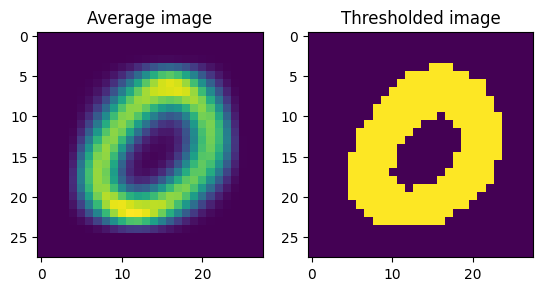

In [4]:
m = np.mean(x, axis=0) # IMPORTANT: indexes in python start at "0", not "1", so the first element of array "a" would be a[0]

plt.figure()
plt.subplot(1,2,1)
plt.imshow(m)
plt.title('Average image')

mt = 1*(m > 60) # Thresholding
plt.subplot(1,2,2)
plt.imshow(mt)
plt.title('Thresholded image')

## From a thresholded image, we can use the regionprops function from skimage.measure

In [5]:
mt_props = measure.regionprops(mt)
num_regions = len(mt_props)
print(str(num_regions)+' region/s were found')
print('')

print('Area (in pixels):')
area = mt_props[0].area # Remember, index 0 is the first region found
print(area)
print('')

print('Perimeter (in pixels):')
perimeter = mt_props[0].perimeter
print(perimeter)
print('')

print('Centroid (pixel coordinates):')
centroid = mt_props[0].centroid
print(centroid)

print('Eccentricity:')
eccentricity = mt_props[0].eccentricity
print(eccentricity)
print('')

print('Minor axis length:')
minor_axis = mt_props[0].minor_axis_length
print(minor_axis)
print('')



1 region/s were found

Area (in pixels):
237.0

Perimeter (in pixels):
93.74011537017762

Centroid (pixel coordinates):
(np.float64(13.978902953586498), np.float64(14.080168776371307))
Eccentricity:
0.6181813464414365

Minor axis length:
18.53176476195907



## Example: Scatter plot of Area vs Perimeter for all images of numbers "number" and "number+1"
### Are "Area" and "Perimeter" good features to classify "number" and "number+1"?

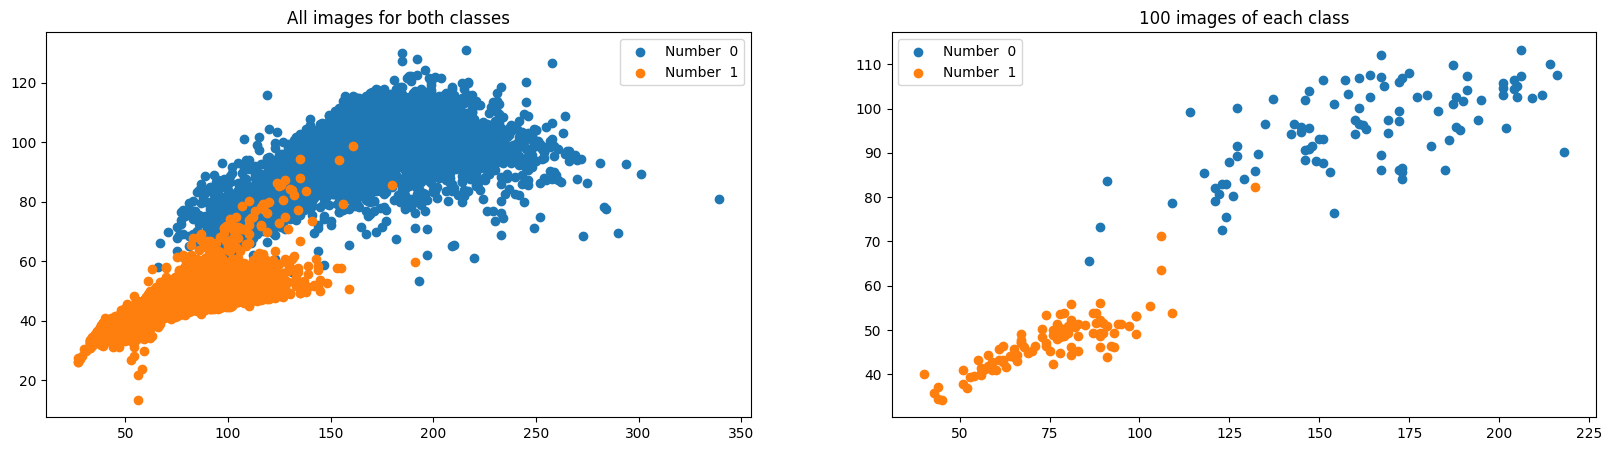

In [6]:
x5 = x_train[y_train==number,:,:]
x6 = x_train[y_train==number+1,:,:]
buf5 = "Number  %d" % number
buf6 = "Number  %d" % (number+1)
# Threshold images
t5 = 1*(x5 > 60)
t6 = 1*(x6 > 60)

# Region properties
area5 = np.zeros(t5.shape[0])
perimeter5 = np.zeros(t5.shape[0])
for i in range(0,t5.shape[0]):
  props = measure.regionprops(t5[i,:,:])
  area5[i] = props[0].area
  perimeter5[i] = props[0].perimeter
  
area6 = np.zeros(t6.shape[0])
perimeter6 = np.zeros(t6.shape[0])
for i in range(0,t6.shape[0]):
  props = measure.regionprops(t6[i,:,:])
  area6[i] = props[0].area
  perimeter6[i] = props[0].perimeter
  
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.scatter(area5,perimeter5, label=buf5)
plt.scatter(area6,perimeter6, label=buf6)
plt.title('All images for both classes')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(area5[0:100],perimeter5[0:100], label=buf5)
plt.scatter(area6[0:100],perimeter6[0:100], label=buf6)
plt.title('100 images of each class')
plt.legend()

In [7]:
x_train_0 = x_train[y_train == 0]
x_train_1 = x_train[y_train == 1]
x_test_0  = x_test[y_test == 0]
x_test_1  = x_test[y_test == 1]

print(f"Training - 0's: {x_train_0.shape[0]}, 1's: {x_train_1.shape[0]}")
print(f"Testing - 0's: {x_test_0.shape[0]}, 1's: {x_test_1.shape[0]}")

t_train_0 = 1*(x_train_0 > 60)
t_train_1 = 1*(x_train_1 > 60)
t_test_0 = 1*(x_test_0 > 60)
t_test_1 = 1*(x_test_1 > 60)

areas_train_0 = np.zeros(t_train_0.shape[0])
perimeters_train_0 = np.zeros(t_train_0.shape[0])
for i in range(t_train_0.shape[0]):
    props = measure.regionprops(t_train_0[i,:,:])
    areas_train_0[i] = props[0].area
    perimeters_train_0[i] = props[0].perimeter

areas_train_1 = np.zeros(t_train_1.shape[0])
perimeters_train_1 = np.zeros(t_train_1.shape[0])
for i in range(t_train_1.shape[0]):
    props = measure.regionprops(t_train_1[i,:,:])
    areas_train_1[i] = props[0].area
    perimeters_train_1[i] = props[0].perimeter

areas_test_0 = np.zeros(t_test_0.shape[0])
perimeters_test_0 = np.zeros(t_test_0.shape[0])
for i in range(t_test_0.shape[0]):
    props = measure.regionprops(t_test_0[i,:,:])
    areas_test_0[i] = props[0].area
    perimeters_test_0[i] = props[0].perimeter

areas_test_1 = np.zeros(t_test_1.shape[0])
perimeters_test_1 = np.zeros(t_test_1.shape[0])
for i in range(t_test_1.shape[0]):
    props = measure.regionprops(t_test_1[i,:,:])
    areas_test_1[i] = props[0].area
    perimeters_test_1[i] = props[0].perimeter

X_train_01 = np.column_stack([areas_train_0, perimeters_train_0])
X_train_01 = np.vstack([X_train_01, np.column_stack([areas_train_1, perimeters_train_1])])
y_train_01 = np.hstack([np.zeros(len(areas_train_0)), np.ones(len(areas_train_1))])

X_test_01 = np.column_stack([areas_test_0, perimeters_test_0])
X_test_01 = np.vstack([X_test_01, np.column_stack([areas_test_1, perimeters_test_1])])
y_test_01 = np.hstack([np.zeros(len(areas_test_0)), np.ones(len(areas_test_1))])

print(f"\nTraining data shape: {X_train_01.shape}")
print(f"Test data shape: {X_test_01.shape}")


Training - 0's: 5923, 1's: 6742
Testing - 0's: 980, 1's: 1135

Training data shape: (12665, 2)
Test data shape: (2115, 2)



Fisher Discriminant (Training)
Class 0 samples: 5923
Class 1 samples: 6742
Balanced training accuracy: 98.65%

Confusion Matrix:
[[5808  115]
 [  51 6691]]
TN = 5808, FP = 115, FN = 51, TP = 6691
Number of misclassified samples: 166


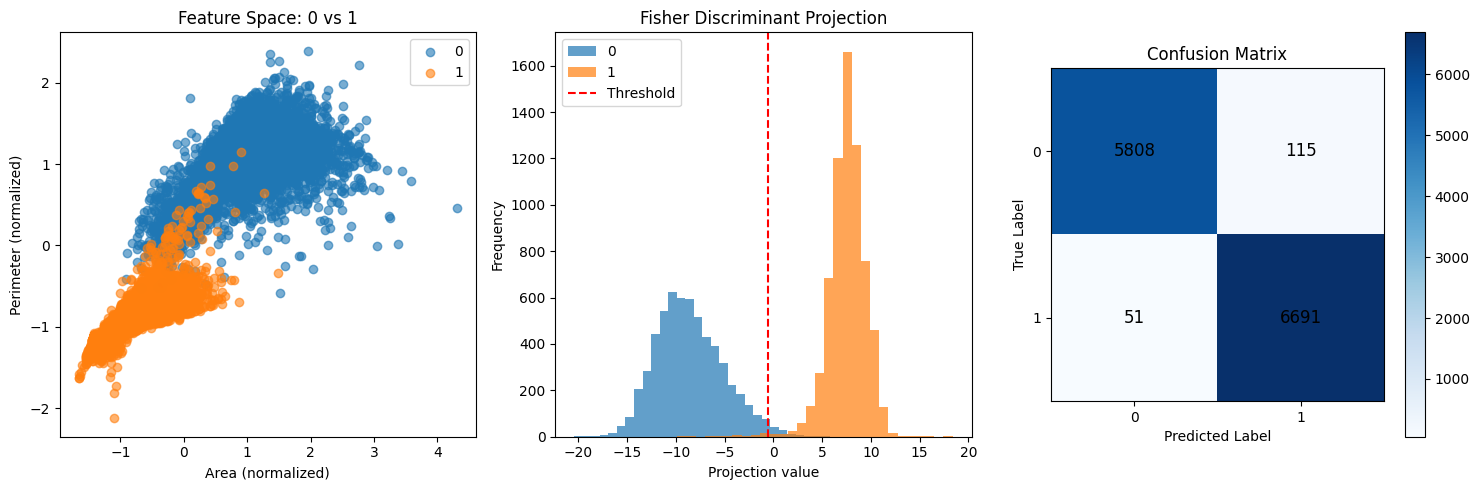

In [8]:
mean = X_train_01.mean(axis=0)
std = X_train_01.std(axis=0)
X_train_01_norm = (X_train_01 - mean) / std
X_test_01_norm  = (X_test_01  - mean) / std

class0 = X_train_01_norm[y_train_01 == 0]
class1 = X_train_01_norm[y_train_01 == 1]

mu0 = np.mean(class0, axis=0)
mu1 = np.mean(class1, axis=0)

S0 = np.cov(class0.T)
S1 = np.cov(class1.T)
Sw = S0 + S1

w = np.linalg.pinv(Sw) @ (mu1 - mu0)

proj_0 = class0 @ w
proj_1 = class1 @ w

threshold = (np.mean(proj_0) + np.mean(proj_1)) / 2

proj_train = X_train_01_norm @ w
y_pred_train = (proj_train > threshold).astype(int)

tp = np.sum((y_train_01 == 1) & (y_pred_train == 1))
tn = np.sum((y_train_01 == 0) & (y_pred_train == 0))
fp = np.sum((y_train_01 == 0) & (y_pred_train == 1))
fn = np.sum((y_train_01 == 1) & (y_pred_train == 0))

conf_matrix = np.array([[tn, fp],[fn, tp]])

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
balanced_acc = 0.5 * (tp / (tp + fn) + specificity)

print("\nFisher Discriminant (Training)")
print(f"Class 0 samples: {len(class0)}")
print(f"Class 1 samples: {len(class1)}")
print(f"Balanced training accuracy: {balanced_acc*100:.2f}%")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

misclassified_idx = np.where(y_pred_train != y_train_01)[0]
num_misclassified = len(misclassified_idx)
print(f"Number of misclassified samples: {num_misclassified}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(class0[:, 0], class0[:, 1], alpha=0.6, label='0')
plt.scatter(class1[:, 0], class1[:, 1], alpha=0.6, label='1')
plt.xlabel('Area (normalized)')
plt.ylabel('Perimeter (normalized)')
plt.title('Feature Space: 0 vs 1')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(proj_0, alpha=0.7, bins=30, label='0')
plt.hist(proj_1, alpha=0.7, bins=30, label='1')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Projection value')
plt.ylabel('Frequency')
plt.title('Fisher Discriminant Projection')
plt.legend()

plt.subplot(1, 3, 3)
plt.imshow(conf_matrix, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()


Fisher Discriminant (Testing)
Number of test 0's: 980
Number of test 1's: 1135
Balanced test accuracy: 99.07%

Confusion Matrix:
[[ 966   14]
 [   5 1130]]
TN = 966, FP = 14, FN = 5, TP = 1130
Number of misclassified samples: 19


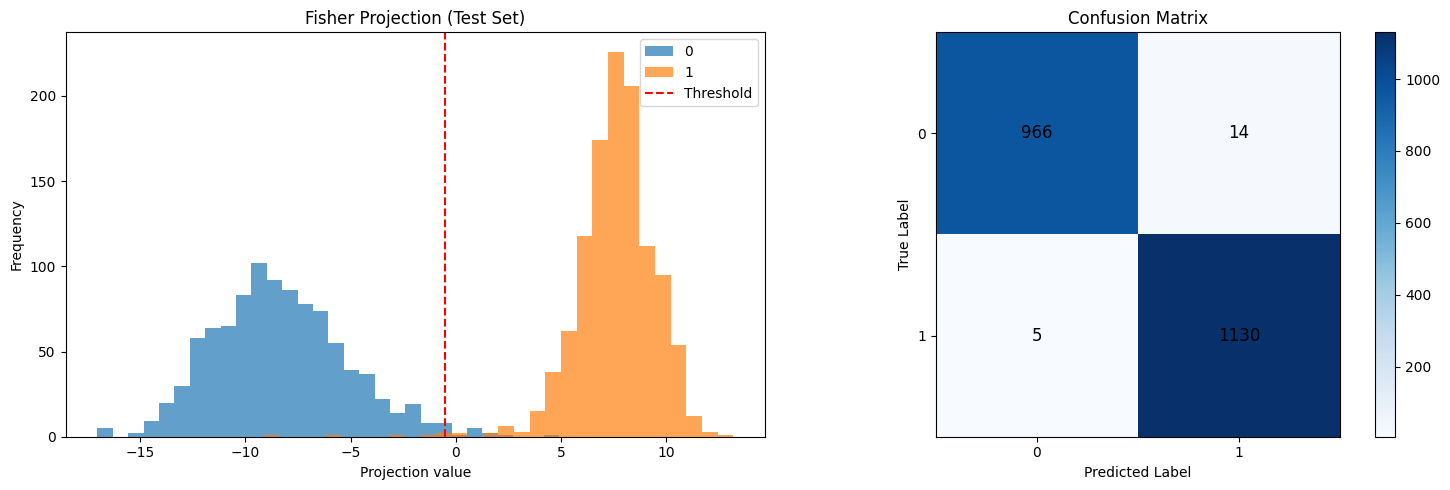

In [9]:
proj_test = X_test_01_norm @ w
y_pred_test = (proj_test > threshold).astype(int)

tp = np.sum((y_test_01 == 1) & (y_pred_test == 1))
tn = np.sum((y_test_01 == 0) & (y_pred_test == 0))
fp = np.sum((y_test_01 == 0) & (y_pred_test == 1))
fn = np.sum((y_test_01 == 1) & (y_pred_test == 0))

conf_matrix = np.array([[tn, fp],[fn, tp]])

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
balanced_acc_test = 0.5 * (tp / (tp + fn) + specificity)

print("\nFisher Discriminant (Testing)")
print(f"Number of test 0's: {np.sum(y_test_01 == 0)}")
print(f"Number of test 1's: {np.sum(y_test_01 == 1)}")
print(f"Balanced test accuracy: {balanced_acc_test*100:.2f}%")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

misclassified_idx = np.where(y_pred_test != y_test_01)[0]
num_misclassified = len(misclassified_idx)
print(f"Number of misclassified samples: {num_misclassified}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(proj_test[y_test_01 == 0], bins=30, alpha=0.7, label='0')
plt.hist(proj_test[y_test_01 == 1], bins=30, alpha=0.7, label='1')
plt.axvline(threshold, color='red', linestyle='--', label='Threshold')
plt.xlabel('Projection value')
plt.ylabel('Frequency')
plt.title('Fisher Projection (Test Set)')
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(conf_matrix, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['0', '1'])
plt.yticks([0, 1], ['0', '1'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix[i, j], ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()


Training - 5's: 5421, 6's: 5918
Testing - 5's: 892, 6's: 958

Training data shape: (11339, 2)
Testing data shape: (1850, 2)

Fisher Discriminant (Training 5 vs 6)
Balanced training accuracy: 64.52%
Confusion matrix:
[[3812 1609]
 [2443 3475]]
TN = 3812, FP = 1609, FN = 2443, TP = 3475
Number of misclassified Training samples: 4052

Fisher Discriminant (Testing 5 vs 6)
Balanced testing accuracy: 62.91%
Confusion matrix:
[[599 293]
 [396 562]]
TN = 599, FP = 293, FN = 396, TP = 562
Number of misclassified Testing samples: 689


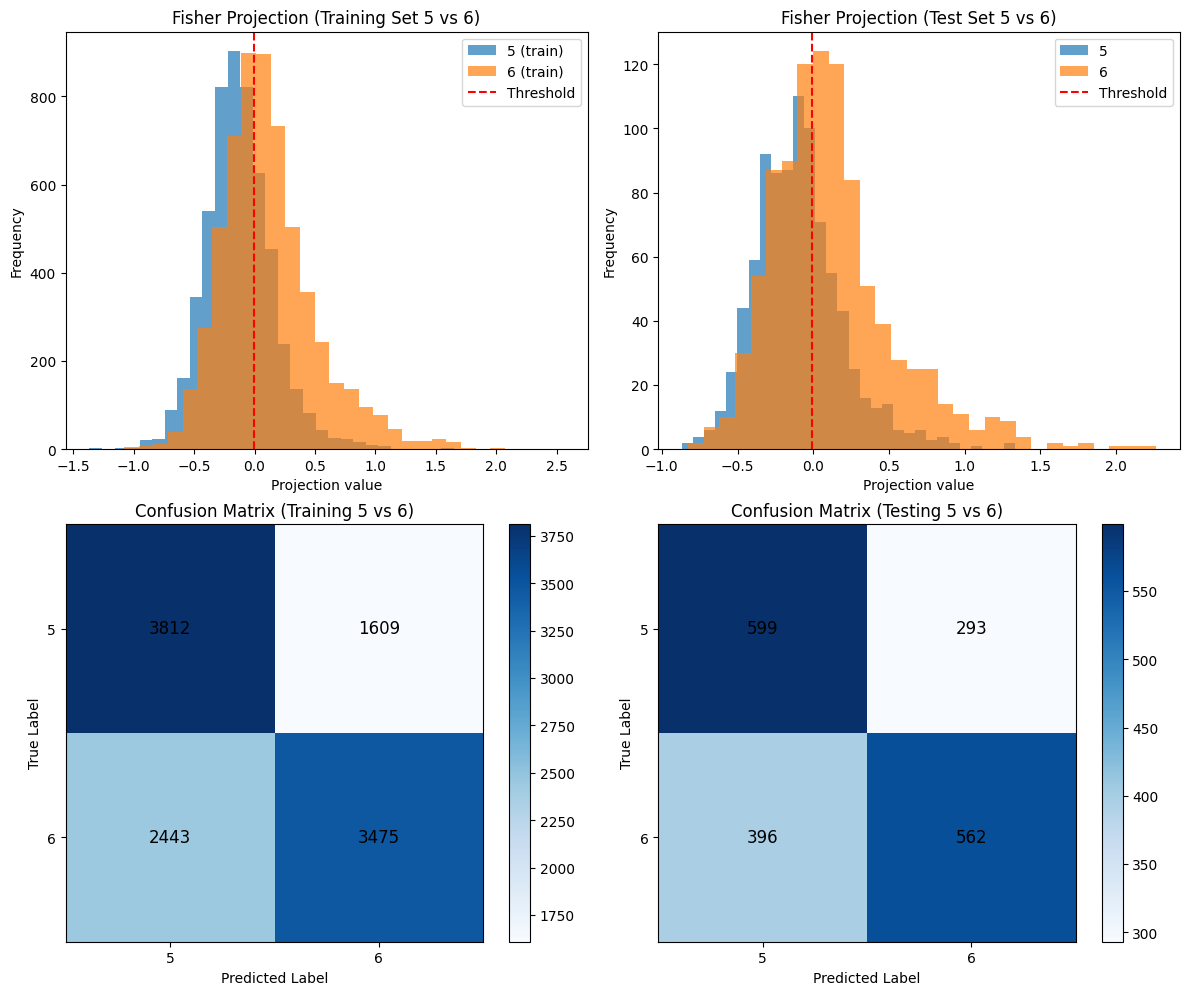

In [10]:
x_train_5 = x_train[y_train == 5]
x_train_6 = x_train[y_train == 6]
x_test_5  = x_test[y_test == 5]
x_test_6  = x_test[y_test == 6]

print(f"Training - 5's: {x_train_5.shape[0]}, 6's: {x_train_6.shape[0]}")
print(f"Testing - 5's: {x_test_5.shape[0]}, 6's: {x_test_6.shape[0]}")

t_train_5 = 1*(x_train_5 > 60)
t_train_6 = 1*(x_train_6 > 60)
t_test_5 = 1*(x_test_5 > 60)
t_test_6 = 1*(x_test_6 > 60)

areas_train_5 = np.zeros(t_train_5.shape[0])
perimeters_train_5 = np.zeros(t_train_5.shape[0])
for i in range(t_train_5.shape[0]):
    props = measure.regionprops(t_train_5[i,:,:])
    areas_train_5[i] = props[0].area
    perimeters_train_5[i] = props[0].perimeter

areas_train_6 = np.zeros(t_train_6.shape[0])
perimeters_train_6 = np.zeros(t_train_6.shape[0])
for i in range(t_train_6.shape[0]):
    props = measure.regionprops(t_train_6[i,:,:])
    areas_train_6[i] = props[0].area
    perimeters_train_6[i] = props[0].perimeter

areas_test_5 = np.zeros(t_test_5.shape[0])
perimeters_test_5 = np.zeros(t_test_5.shape[0])
for i in range(t_test_5.shape[0]):
    props = measure.regionprops(t_test_5[i,:,:])
    areas_test_5[i] = props[0].area
    perimeters_test_5[i] = props[0].perimeter

areas_test_6 = np.zeros(t_test_6.shape[0])
perimeters_test_6 = np.zeros(t_test_6.shape[0])
for i in range(t_test_6.shape[0]):
    props = measure.regionprops(t_test_6[i,:,:])
    areas_test_6[i] = props[0].area
    perimeters_test_6[i] = props[0].perimeter

X_train_56 = np.column_stack([areas_train_5, perimeters_train_5])
X_train_56 = np.vstack([X_train_56, np.column_stack([areas_train_6, perimeters_train_6])])
y_train_56 = np.hstack([np.zeros(len(areas_train_5)), np.ones(len(areas_train_6))])

X_test_56 = np.column_stack([areas_test_5, perimeters_test_5])
X_test_56 = np.vstack([X_test_56, np.column_stack([areas_test_6, perimeters_test_6])])
y_test_56 = np.hstack([np.zeros(len(areas_test_5)), np.ones(len(areas_test_6))])

print(f"\nTraining data shape: {X_train_56.shape}")
print(f"Testing data shape: {X_test_56.shape}")

mean_56 = X_train_56.mean(axis=0)
std_56 = X_train_56.std(axis=0)
X_train_56_norm = (X_train_56 - mean_56) / std_56
X_test_56_norm  = (X_test_56  - mean_56) / std_56

class5 = X_train_56_norm[y_train_56 == 0]
class6 = X_train_56_norm[y_train_56 == 1]

mu5 = np.mean(class5, axis=0)
mu6 = np.mean(class6, axis=0)

S5 = np.cov(class5.T)
S6 = np.cov(class6.T)
Sw_56 = S5 + S6

w_56 = np.linalg.pinv(Sw_56) @ (mu6 - mu5)

proj_5 = class5 @ w_56
proj_6 = class6 @ w_56
threshold_56 = (np.mean(proj_5) + np.mean(proj_6)) / 2

proj_train_56 = X_train_56_norm @ w_56
y_pred_train_56 = (proj_train_56 > threshold_56).astype(int)

tp_56_train = np.sum((y_train_56 == 1) & (y_pred_train_56 == 1))
tn_56_train = np.sum((y_train_56 == 0) & (y_pred_train_56 == 0))
fp_56_train = np.sum((y_train_56 == 0) & (y_pred_train_56 == 1))
fn_56_train = np.sum((y_train_56 == 1) & (y_pred_train_56 == 0))
conf_matrix_56_train = np.array([[tn_56_train, fp_56_train],[fn_56_train, tp_56_train]])

sensitivity_train = tp_56_train / (tp_56_train + fn_56_train)
specificity_train = tn_56_train / (tn_56_train + fp_56_train)
balanced_acc_train_56 = 0.5 * (tp_56_train / (tp_56_train + fn_56_train) + specificity_train)

print("\nFisher Discriminant (Training 5 vs 6)")
print(f"Balanced training accuracy: {balanced_acc_train_56*100:.2f}%")
print("Confusion matrix:")
print(conf_matrix_56_train)
print(f"TN = {tn_56_train}, FP = {fp_56_train}, FN = {fn_56_train}, TP = {tp_56_train}")

misclassified_idx_Training56 = np.where(y_pred_train_56 != y_train_56)[0]
num_misclassified_Training56 = len(misclassified_idx_Training56)
print(f"Number of misclassified Training samples: {num_misclassified_Training56}")

proj_test_56 = X_test_56_norm @ w_56
y_pred_test_56 = (proj_test_56 > threshold_56).astype(int)

tp_56_test = np.sum((y_test_56 == 1) & (y_pred_test_56 == 1))
tn_56_test = np.sum((y_test_56 == 0) & (y_pred_test_56 == 0))
fp_56_test = np.sum((y_test_56 == 0) & (y_pred_test_56 == 1))
fn_56_test = np.sum((y_test_56 == 1) & (y_pred_test_56 == 0))
conf_matrix_56_test = np.array([[tn_56_test, fp_56_test],[fn_56_test, tp_56_test]])

sensitivity_test = tp_56_test / (tp_56_test + fn_56_test)
specificity_test = tn_56_test / (tn_56_test + fp_56_test)
balanced_acc_test_56 = 0.5 * (tp_56_test / (tp_56_test + fn_56_test) + specificity_test)

print("\nFisher Discriminant (Testing 5 vs 6)")
print(f"Balanced testing accuracy: {balanced_acc_test_56*100:.2f}%")
print("Confusion matrix:")
print(conf_matrix_56_test)
print(f"TN = {tn_56_test}, FP = {fp_56_test}, FN = {fn_56_test}, TP = {tp_56_test}")

misclassified_idx_Testing56 = np.where(y_pred_test_56 != y_test_56)[0]
num_misclassified_Testing56 = len(misclassified_idx_Testing56)
print(f"Number of misclassified Testing samples: {num_misclassified_Testing56}")

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.hist(proj_train_56[y_train_56 == 0], bins=30, alpha=0.7, label='5 (train)')
plt.hist(proj_train_56[y_train_56 == 1], bins=30, alpha=0.7, label='6 (train)')
plt.axvline(threshold_56, color='red', linestyle='--', label='Threshold')
plt.xlabel('Projection value')
plt.ylabel('Frequency')
plt.title('Fisher Projection (Training Set 5 vs 6)')
plt.legend()

plt.subplot(2,2,2)
plt.hist(proj_test_56[y_test_56 == 0], bins=30, alpha=0.7, label='5')
plt.hist(proj_test_56[y_test_56 == 1], bins=30, alpha=0.7, label='6')
plt.axvline(threshold_56, color='red', linestyle='--', label='Threshold')
plt.xlabel('Projection value')
plt.ylabel('Frequency')
plt.title('Fisher Projection (Test Set 5 vs 6)')
plt.legend()

plt.subplot(2,2,3)
plt.imshow(conf_matrix_56_train, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix (Training 5 vs 6)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0,1], ['5','6'])
plt.yticks([0,1], ['5','6'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix_56_train[i,j], ha='center', va='center', color='black', fontsize=12)

plt.subplot(2,2,4)
plt.imshow(conf_matrix_56_test, cmap='Blues')
plt.colorbar()
plt.title('Confusion Matrix (Testing 5 vs 6)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0,1], ['5','6'])
plt.yticks([0,1], ['5','6'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_matrix_56_test[i,j], ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()